In [ ]:
# Cell 1

import numpy as np
import random
import time

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.metrics import accuracy_score, roc_auc_score, f1_score
import matplotlib.pyplot as plt
import pandas as pd

# 재현성을 위한 시드 고정
SEED = 42
np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))


TensorFlow: 2.19.0
GPU available: []


In [ ]:
# Cell 2: IMDB 데이터 로드 및 전처리

# 하이퍼파라미터
VOCAB_SIZE = 20000
MAXLEN = 200
EMBED_DIM = 128
RNN_UNITS = 64
BATCH_SIZE = 128
EPOCHS = 5

# 1. 데이터 로드
(x_train, y_train), (x_test, y_test) = keras.datasets.imdb.load_data(num_words=VOCAB_SIZE)

print("원본 train 개수:", len(x_train))
print("원본 test  개수:", len(x_test))

# 2. 시퀀스 길이 맞추기
x_train = keras.preprocessing.sequence.pad_sequences(x_train, maxlen=MAXLEN, padding='post', truncating='post')
x_test  = keras.preprocessing.sequence.pad_sequences(x_test,  maxlen=MAXLEN, padding='post', truncating='post')

print("패딩 후 train shape:", x_train.shape)
print("패딩 후 test shape :", x_test.shape)

# 3. train/validation
VAL_SIZE = 5000
x_val = x_train[-VAL_SIZE:]
y_val = y_train[-VAL_SIZE:]
x_train_small = x_train[:-VAL_SIZE]
y_train_small = y_train[:-VAL_SIZE]

print("실제 학습 데이터:", x_train_small.shape, "라벨:", y_train_small.shape)
print("검증 데이터:", x_val.shape, "라벨:", y_val.shape)
print("테스트 데이터:", x_test.shape, "라벨:", y_test.shape)


17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
원본 train 개수: 25000
원본 test  개수: 25000
패딩 후 train shape: (25000, 200)
패딩 후 test shape : (25000, 200)
실제 학습 데이터: (20000, 200) 라벨: (20000,)
검증 데이터: (5000, 200) 라벨: (5000,)
테스트 데이터: (25000, 200) 라벨: (25000,)


In [ ]:
# Cell 3: 모델 생성 함수 정의

def build_model(model_type: str,
                vocab_size: int = VOCAB_SIZE,
                embed_dim: int = EMBED_DIM,
                maxlen: int = MAXLEN,
                rnn_units: int = RNN_UNITS,
                lr: float = 1e-3) -> keras.Model:
    """
    model_type: 'rnn', 'lstm', 'gru', 'bilstm'
    """
    inputs = keras.Input(shape=(maxlen,), dtype="int32")
    x = layers.Embedding(vocab_size, embed_dim, input_length=maxlen)(inputs)
    x = layers.SpatialDropout1D(0.2)(x)

    if model_type == "rnn":
        x = layers.SimpleRNN(rnn_units)(x)
    elif model_type == "lstm":
        x = layers.LSTM(rnn_units)(x)
    elif model_type == "gru":
        x = layers.GRU(rnn_units)(x)
    elif model_type == "bilstm":
        x = layers.Bidirectional(layers.LSTM(rnn_units))(x)
    else:
        raise ValueError(f"Unknown model_type: {model_type}")

    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(1, activation="sigmoid")(x)

    model = keras.Model(inputs, outputs, name=f"imdb_{model_type}")
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )
    return model

# 테스트로 한 번 구조 확인
test_model = build_model("lstm")
test_model.summary()
test_model = None


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "imdb_lstm"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 200)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ (None, 200, 128)       │     2,560,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ (None, 200, 128)       │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,609,473 (9.95 MB)

 Trainable params: 2,609,473 (9.95 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Cell 4: 4개 모델 학습 및 평가

model_types = ["rnn", "lstm", "gru", "bilstm"]

histories = {}    # 각 모델의 History 객체 저장
results = []      # 결과 요약 저장용

for mtype in model_types:
    print("\n" + "=" * 60)
    print(f"▶▶ 모델 타입: {mtype}")
    print("=" * 60)

    model = build_model(mtype)
    model.summary()

    # 파라미터 수
    param_count = model.count_params()

    # 학습
    start_time = time.time()
    history = model.fit(
        x_train_small, y_train_small,
        validation_data=(x_val, y_val),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        verbose=1
    )
    end_time = time.time()
    train_time = end_time - start_time   # 초 단위

    histories[mtype] = history

    # 테스트 평가
    y_proba = model.predict(x_test, batch_size=BATCH_SIZE)
    y_pred = (y_proba >= 0.5).astype("int32")

    acc = accuracy_score(y_test, y_pred)
    try:
        auc = roc_auc_score(y_test, y_proba)
    except ValueError:
        # 모두 같은 값으로 예측되는 극단적인 경우를 대비한 예외 처리
        auc = np.nan
    f1 = f1_score(y_test, y_pred)

    print(f"[{mtype}] Test Accuracy: {acc:.4f}, AUROC: {auc:.4f}, F1: {f1:.4f}")
    print(f"[{mtype}] Train time: {train_time:.2f} sec, Params: {param_count}")

    results.append({
        "Model": mtype.upper(),
        "Test_Accuracy": acc,
        "Test_AUROC": auc,
        "Test_F1": f1,
        "Train_Time_sec": train_time,
        "Param_Count": param_count
    })

# 결과를 DataFrame으로 정리
results_df = pd.DataFrame(results)
results_df



▶▶ 모델 타입: rnn


Model: "imdb_rnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 200)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_1 (Embedding)         │ (None, 200, 128)       │     2,560,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_1             │ (None, 200, 128)       │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 64)             │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,572,417 (9.81 MB)

 Trainable params: 2,572,417 (9.81 MB)

...

 Total params: 2,658,945 (10.14 MB)

 Trainable params: 2,658,945 (10.14 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 119s 735ms/step - accuracy: 0.6072 - loss: 0.6259 - val_accuracy: 0.8420 - val_loss: 0.3676
Epoch 2/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 116s 741ms/step - accuracy: 0.8669 - loss: 0.3324 - val_accuracy: 0.8668 - val_loss: 0.3337
Epoch 3/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 141s 734ms/step - accuracy: 0.9203 - loss: 0.2200 - val_accuracy: 0.8656 - val_loss: 0.3592
Epoch 4/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 154s 810ms/step - accuracy: 0.9348 - loss: 0.1848 - val_accuracy: 0.8578 - val_loss: 0.3673
Epoch 5/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 130s 734ms/step - accuracy: 0.9497 - loss: 0.1434 - val_accuracy: 0.8584 - val_loss: 0.4281
196/196 ━━━━━━━━━━━━━━━━━━━━ 40s 204ms/step
[bilstm] Test Accuracy: 0.8233, AUROC: 0.8974, F1: 0.8126
[bilstm] Train time: 660.23 sec, Params: 2658945


,Model,Test_Accuracy,Test_AUROC,Test_F1,Train_Time_sec,Param_Count
0,RNN,0.50360,0.505148,0.489048,191.810571,2572417
1,LSTM,0.51152,0.535312,0.554729,350.350951,2609473
2,GRU,0.80752,0.910772,0.783886,385.666645,2597313
3,BILSTM,0.82328,0.897436,0.812606,660.234874,2658945


In [ ]:
# Cell 5: 결과 표 정리 출력
display_df = results_df.copy()
display_df["Test_Accuracy"] = display_df["Test_Accuracy"].map(lambda x: f"{x:.4f}")
display_df["Test_AUROC"] = display_df["Test_AUROC"].map(lambda x: f"{x:.4f}" if not np.isnan(x) else "nan")
display_df["Test_F1"] = display_df["Test_F1"].map(lambda x: f"{x:.4f}")
display_df["Train_Time_sec"] = display_df["Train_Time_sec"].map(lambda x: f"{x:.2f}")

display_df.sort_values("Test_Accuracy", ascending=False, inplace=True)
display_df.reset_index(drop=True, inplace=True)

display_df


,Model,Test_Accuracy,Test_AUROC,Test_F1,Train_Time_sec,Param_Count
0,BILSTM,0.8233,0.8974,0.8126,660.23,2658945
1,GRU,0.8075,0.9108,0.7839,385.67,2597313
2,LSTM,0.5115,0.5353,0.5547,350.35,2609473
3,RNN,0.5036,0.5051,0.4890,191.81,2572417


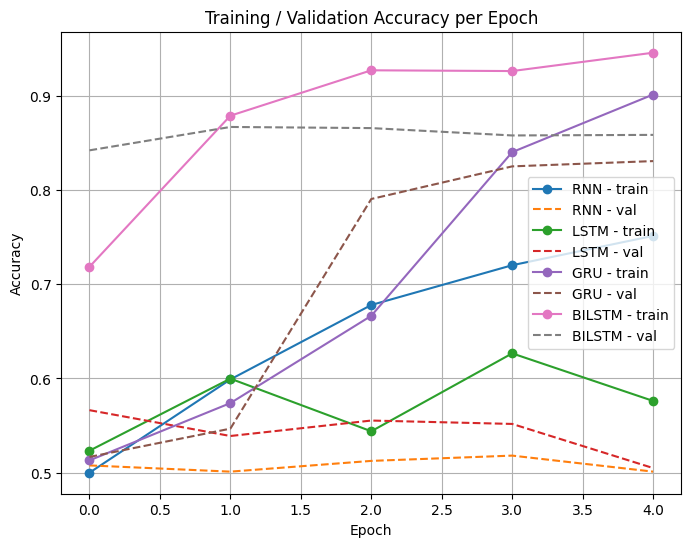

In [ ]:
# Cell 6: 학습 곡선 (Accuracy) 시각화

plt.figure(figsize=(8, 6))

for mtype in model_types:
    hist = histories[mtype].history
    plt.plot(hist["accuracy"], marker="o", label=f"{mtype.upper()} - train")
    plt.plot(hist["val_accuracy"], linestyle="--", label=f"{mtype.upper()} - val")

plt.title("Training / Validation Accuracy per Epoch")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()


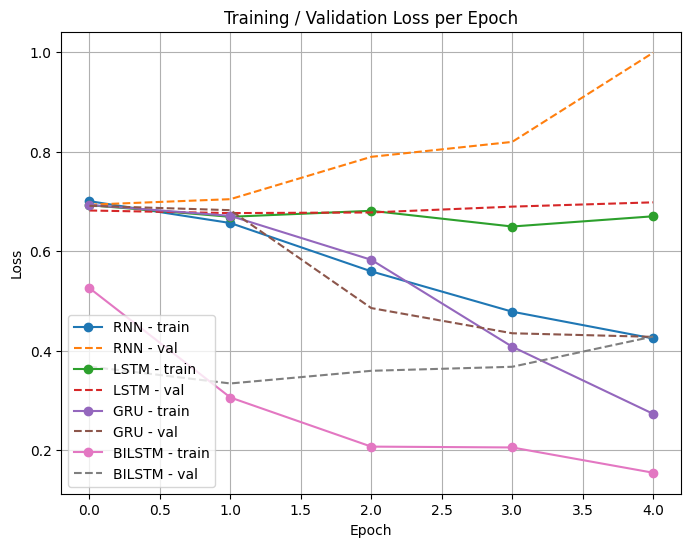

In [ ]:
# Cell 7: 학습 곡선 (Loss) 시각화

plt.figure(figsize=(8, 6))

for mtype in model_types:
    hist = histories[mtype].history
    plt.plot(hist["loss"], marker="o", label=f"{mtype.upper()} - train")
    plt.plot(hist["val_loss"], linestyle="--", label=f"{mtype.upper()} - val")

plt.title("Training / Validation Loss per Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()
